# Notes

Currently time series work even with duplicate measurement, but they are all on different graphs. Leaving that for now. Need to do soil profiles and check soil moisture and snow depth across sites.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import os
import matplotlib.cm as cm
from io import StringIO
import sys
import nc_time_axis
import os

sys.path.append('C:/Users/madel/Code/GeoNorth')

from utils import *

In [2]:
site = "TVC"
vari = "TSOI"
ctsm_file = f"..\\CTSM_data\\run_1\\merged_files\\{site}_1995-2014.nc"
df = xr.open_dataset(ctsm_file, engine="netcdf4")
ds_ctsm = df[f"{vari}"]
ds = xr.open_dataset(f"../Observational_data/{site}_obs/processed/{site}_{vari}.nc")
ds_obs = ds[f"{vari}"]
ds_obs = ds_obs.sortby("depth")

C:\Users\madel\AppData\Local\Temp\ipykernel_17568\727719220.py:4: FutureWarning: In a future version, xarray will not decode the variable 'SNOW_PERSISTENCE' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  df = xr.open_dataset(ctsm_file, engine="netcdf4")


In [3]:
ds_ctsm

<xarray.DataArray 'TSOI' (time: 7300, levgrnd: 25, lndgrid: 1)> Size: 730kB
[182500 values with dtype=float32]
Coordinates:
  * time     (time) object 58kB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
  * levgrnd  (levgrnd) float32 100B 0.01 0.04 0.09 0.16 ... 19.48 28.87 42.0
Dimensions without coordinates: lndgrid
Attributes:
    long_name:      soil temperature (natural vegetated and crop landunits only)
    units:          K
    cell_methods:   time: mean
    landunit_mask:  veg

In [4]:
ds_obs

<xarray.DataArray 'TSOI' (time: 350353, depth: 16)> Size: 45MB
[5605648 values with dtype=float64]
Coordinates:
  * time     (time) object 3MB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
  * depth    (depth) float64 128B 0.05 0.1 0.101 0.102 ... 0.9 1.04 1.16 1.17
Attributes:
    units:    °C

## Interpolation

defining the interpolation function here

In [5]:
# Need to make sure it rounds to 2 decimal points for 0.101 is only interpolating to 0.10


da_interp = interpolate_to_depth(df, ds_obs.depth)

In [6]:
da_interp

<xarray.Dataset> Size: 993kB
Dimensions:  (time: 7300, depth: 16)
Coordinates:
  * time     (time) object 58kB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
  * depth    (depth) float64 128B 0.05 0.1 0.101 0.102 ... 0.9 1.04 1.16 1.17
Data variables:
    TSOI     (time, depth) float64 934kB -0.9384 -1.78 -1.817 ... -8.587 -8.568

## Plotting

defining the plotting funtion for it to be run a few times

In [7]:
def rmse_from_means(obs_mean, sim_mean):
    """RMSE between two equal-length lists of monthly means, skipping NaNs."""
    o = np.array(obs_mean, dtype=float)
    s = np.array(sim_mean, dtype=float)
    mask = ~(np.isnan(o) | np.isnan(s))
    if not mask.any():
        return np.nan
    return float(np.sqrt(np.mean((o[mask] - s[mask]) ** 2)))

In [8]:
final_plot_tsoi(ds_obs, da_interp, f"{site}", ds_obs.depth, f"{vari}")

In [ ]:
def seasonal_plot_tsoi_full(obs, sim, site, depths, vari, show=0):
    # Resample obs to daily
    obs_daily = obs.resample(time="1D").mean()

    # Water-year order: Sep -> Aug
    season = ["Fall", "Winter", "Spring", "Summer"]
    
    month_order = [ 9, 10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8]
    month_labels = ["S","O", "N", "D", "J", "F", "M", "A", "M", "J", "J", "A"]
    x = np.arange(len(month_order))

    for depth_x in depths:
        #gets rid of the .X i add to the end of depths if there are duplicates
        act_val = round(float(depth_x.values), 2)

        # Monthly means, one value per year per month
        obs_sel = obs_daily.sel(depth=depth_x.values, method="nearest")
        sim_sel = sim.sel(depth=act_val, method="nearest")
        sim_depth = sim_sel.depth.values
        print(sim_depth)

        obs_monthly = obs_sel.resample(time="1ME").mean(skipna=True)
        sim_monthly = sim_sel.resample(time="1ME").mean(skipna=True)

        obs_mean, obs_min, obs_max = [], [], []
        sim_mean, sim_min, sim_max = [], [], []

        #could be cleaned up but whatever for now
        for m in month_order:
            ov = obs_monthly.sel(time=obs_monthly["time"].dt.month == m).values
            sv = sim_monthly.sel(time=sim_monthly["time"].dt.month == m).values
            ov = np.asarray(ov, dtype=float)
            sv = np.asarray(sv, dtype=float)
            ov = ov[~np.isnan(ov)]
            sv = sv[~np.isnan(sv)]

            obs_mean.append(np.mean(ov) if len(ov) else np.nan)
            obs_min.append(np.min(ov) if len(ov) else np.nan)
            obs_max.append(np.max(ov) if len(ov) else np.nan)

            sim_mean.append(np.mean(sv) if len(sv) else np.nan)
            sim_min.append(np.min(sv) if len(sv) else np.nan)
            sim_max.append(np.max(sv) if len(sv) else np.nan)

        plt.figure(figsize=(8, 5))
        # Shade background by season (Fall/Winter/Spring/Summer, water-year order)
        season_colors = {"Fall": "goldenrod", "Winter": "steelblue", "Spring": "mediumseagreen", "Summer": "indianred"}
        season_bounds = [(-0.5, 2.5, "Fall"), (2.5, 5.5, "Winter"), (5.5, 8.5, "Spring"), (8.5, 11.5, "Summer")]
        for start, end, sname in season_bounds:
            plt.axvspan(start, end, color=season_colors[sname], alpha=0.08)
        plt.plot(x, obs_mean, "-", color="gray", label=f"Observed - {act_val*100:.0f}cm", linewidth=2)
        plt.fill_between(x, obs_min, obs_max, color="gray", alpha=0.3)

        plt.plot(x, sim_mean, "-", color="crimson", label=f"Simulated - {sim_depth*100:.0f}cm", linewidth=2)
        plt.fill_between(x, sim_min, sim_max, color="crimson", alpha=0.3)

        plt.xticks(x, month_labels)
        plt.xlabel("Month")
        plt.ylabel("Soil Temperature (C)")
        plt.title(f"Seasonal Soil Temperature at {site} - {act_val*100:.0f}cm")
        plt.grid(True)
        plt.legend()

        remain = int(round(depth_x.values - act_val, 3) * 1000)
        #plt.savefig(f"v1.0_final_images/{site}/{vari}/{site}_{vari}_{act_val*100:.0f}cm_{remain}_seasonal.png")
        if not show:
            plt.close()

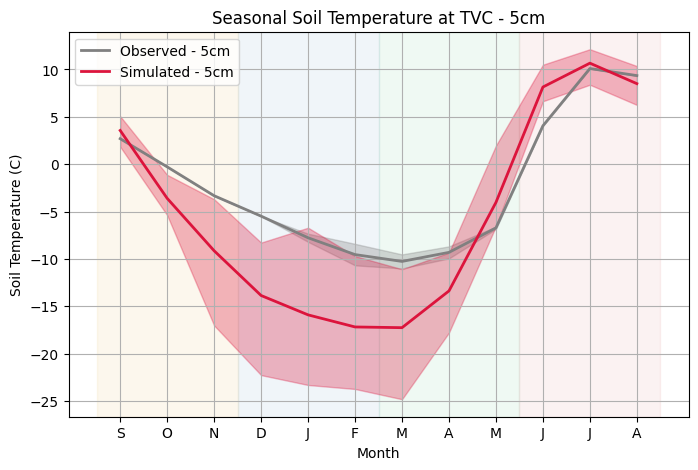

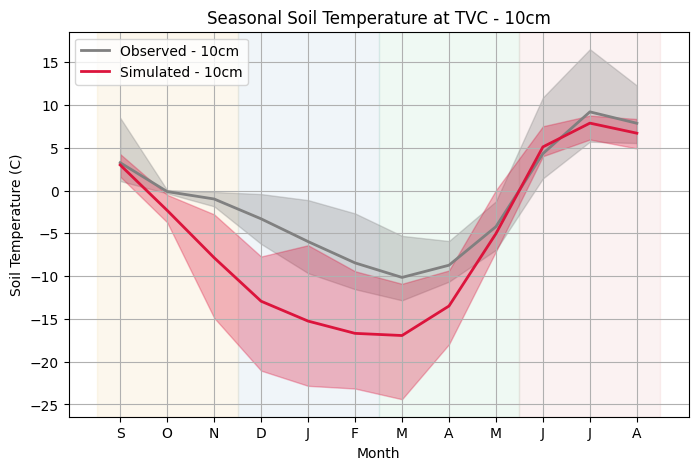

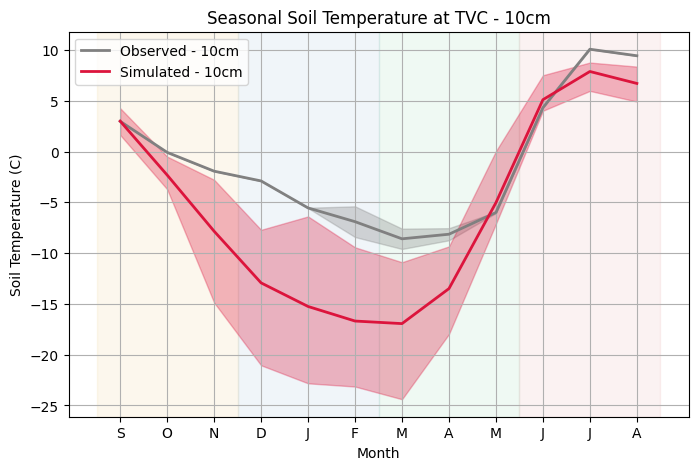

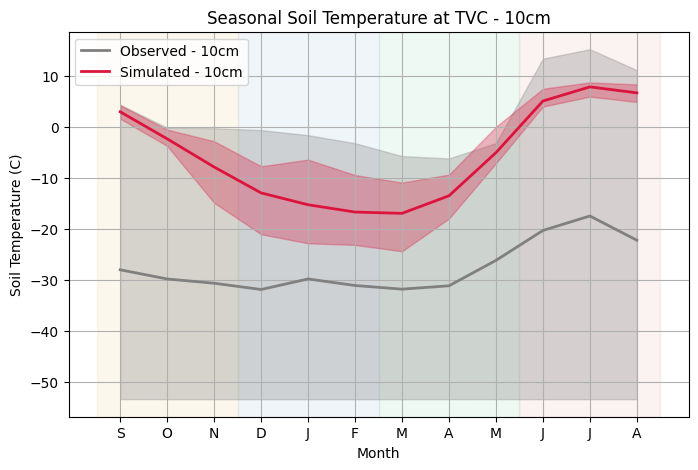

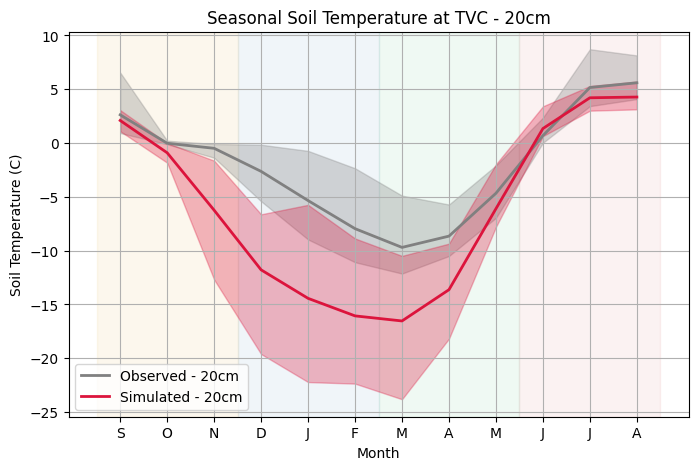

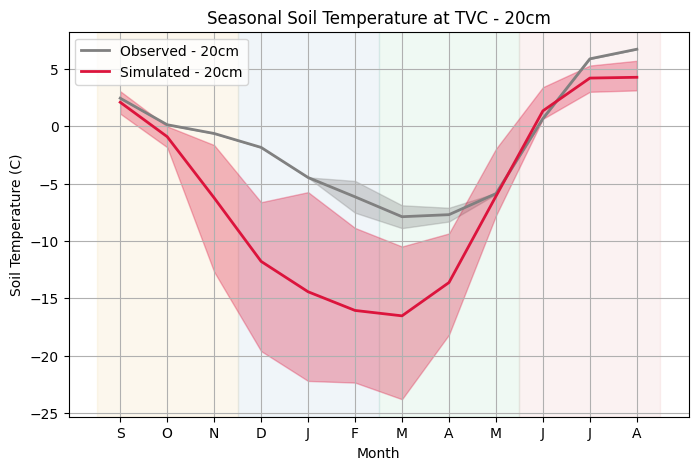

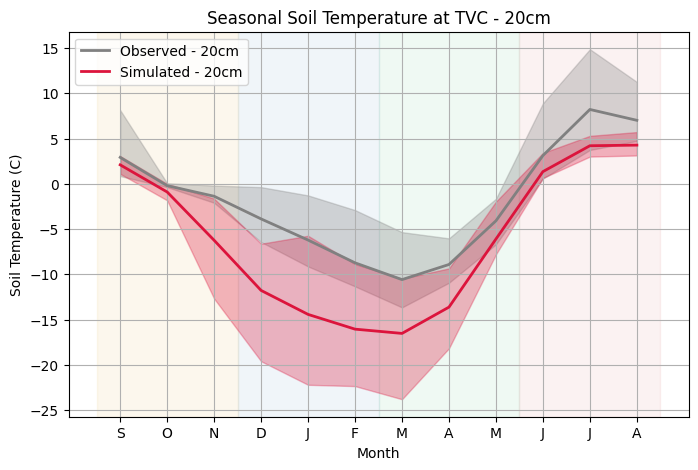

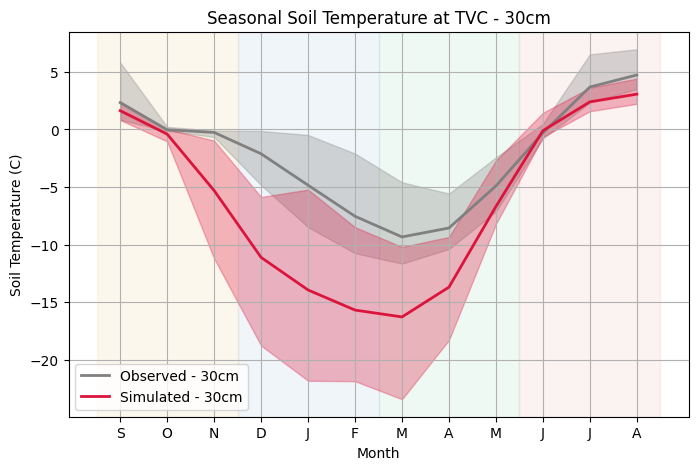

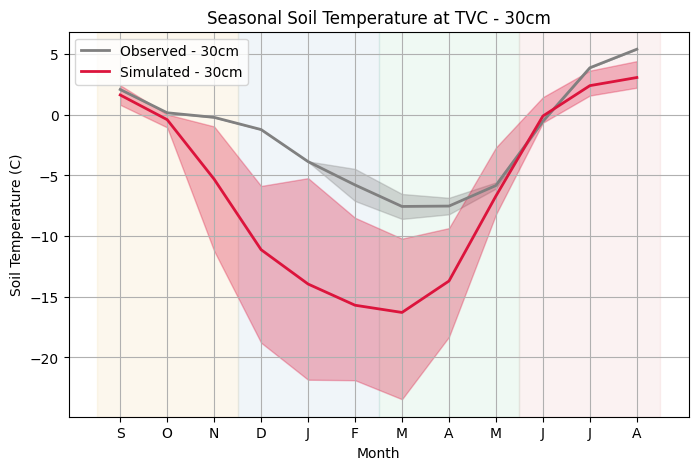

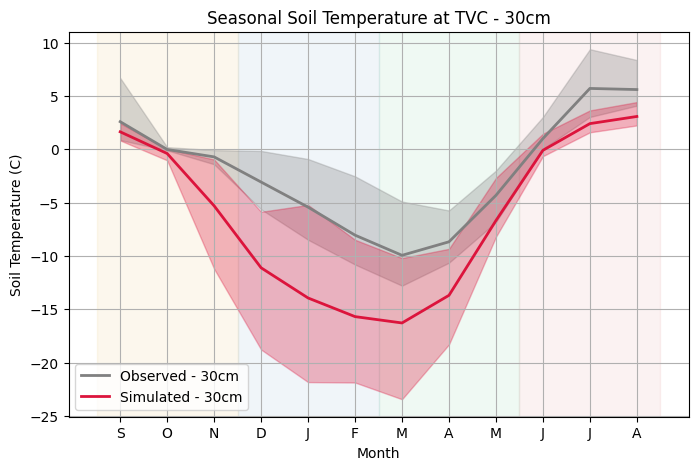

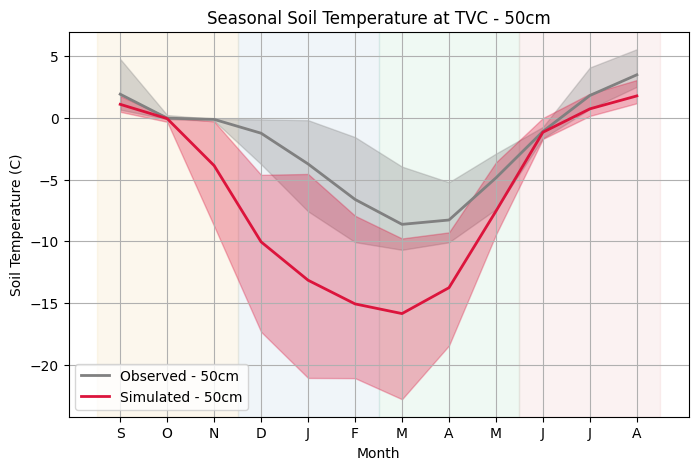

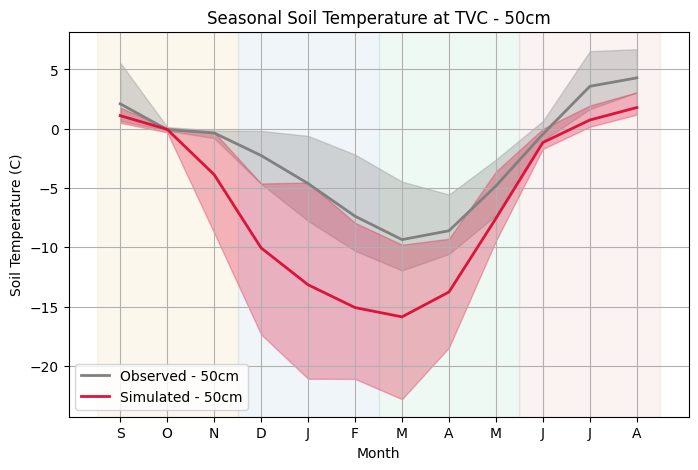

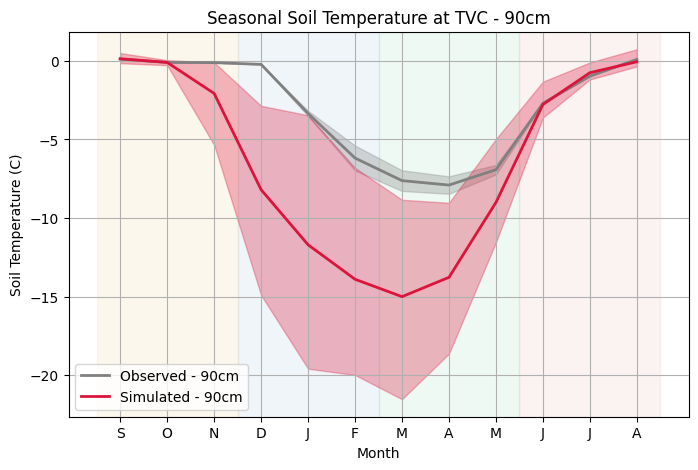

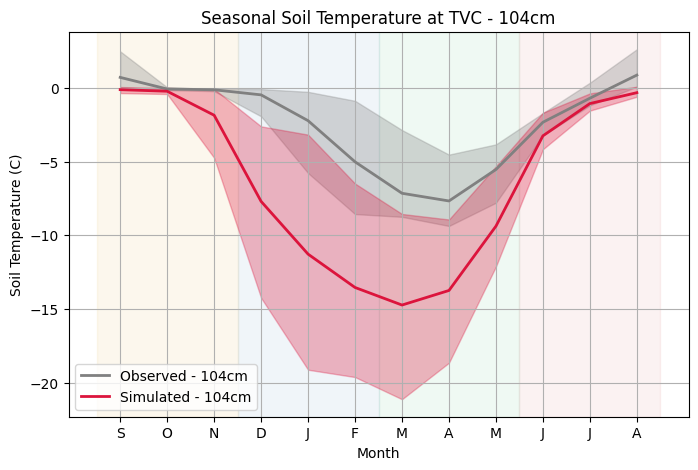

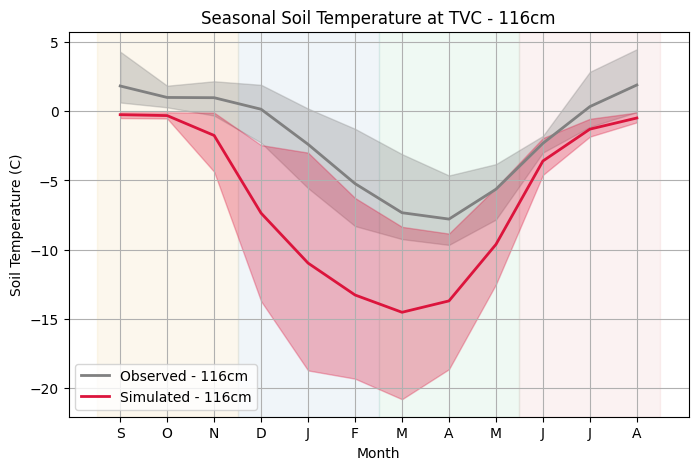

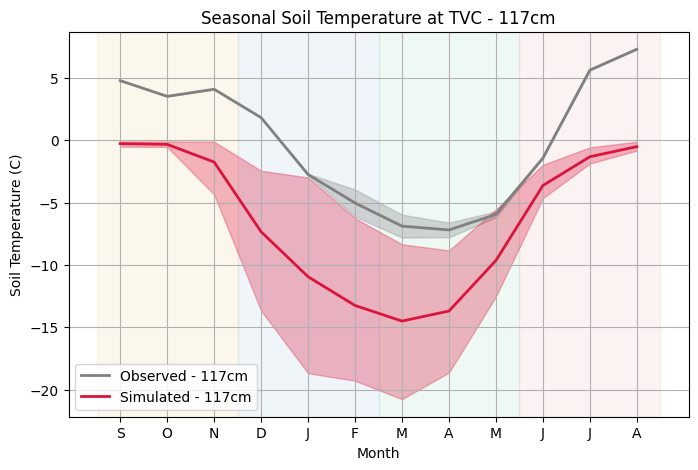

In [ ]:
da_interp_da = da_interp["TSOI"]
seasonal_plot_tsoi_full(ds_obs, da_interp_da, f"{site}", ds_obs.depth, f"{vari}", show=1)
#seasonal_plot_tsoi_full(ds_obs, da_interp, f"{site}", ds_obs.depth, f"{vari}", show=1)

In [143]:
ds_obs

<xarray.DataArray 'TSOI' (time: 350353, depth: 16)> Size: 45MB
[5605648 values with dtype=float64]
Coordinates:
  * time     (time) object 3MB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
  * depth    (depth) float64 128B 0.05 0.1 0.101 0.102 ... 0.9 1.04 1.16 1.17
Attributes:
    units:    °C

In [64]:
import numpy as np
import pandas as pd
import xarray as xr

def compute_rmse_tsoi(obs, sim, depths, vari):
    """
    Compute RMSE, bias, correlation, and unbiased RMSE between observed and
    simulated soil temperature (TSOI) for the full year and for each season,
    at each requested depth.

    Returns a pandas DataFrame with columns:
    depth_cm, sim_depth_cm, period, rmse, bias, corr, ubrmse, n
    """
    # allow obs/sim to be passed as a Dataset or an already-selected DataArray
    if isinstance(obs, xr.Dataset):
        obs = obs[vari]
    if isinstance(sim, xr.Dataset):
        sim = sim[vari]

    obs_daily = obs.resample(time="1D").mean()
    sim = sim.squeeze()  # drop any leftover size-1 dims like lndgrid

    season_months = {
        "Fall":   [9, 10, 11],
        "Winter": [12, 1, 2],
        "Spring": [3, 4, 5],
        "Summer": [6, 7, 8],
    }

    def compute_stats(o, s):
        if len(o) < 2:
            return {"rmse": np.nan, "bias": np.nan, "corr": np.nan, "ubrmse": np.nan}

        o_vals, s_vals = o.values, s.values
        bias = float(np.mean(s_vals - o_vals))
        rmse = float(np.sqrt(np.mean((o_vals - s_vals) ** 2)))
        ubrmse = float(np.sqrt(np.mean(((s_vals - s_vals.mean()) - (o_vals - o_vals.mean())) ** 2)))
        if np.std(o_vals) == 0 or np.std(s_vals) == 0:
            corr = np.nan
        else:
            corr = float(np.corrcoef(o_vals, s_vals)[0, 1])

        return {"rmse": rmse, "bias": bias, "corr": corr, "ubrmse": ubrmse}

    results = []

    for depth_x in depths:
        act_val = round(float(depth_x.values), 2)

        obs_sel = obs_daily.sel(depth=depth_x.values, method="nearest")
        sim_sel = sim.sel(depth=act_val, method="nearest")   # <-- "depth", not "levsoi"
        sim_depth = float(sim_sel.depth.values)

        obs_keys = pd.MultiIndex.from_arrays([
            obs_sel["time"].dt.year.values,
            obs_sel["time"].dt.month.values,
            obs_sel["time"].dt.day.values,
        ])
        sim_keys = pd.MultiIndex.from_arrays([
            sim_sel["time"].dt.year.values,
            sim_sel["time"].dt.month.values,
            sim_sel["time"].dt.day.values,
        ])

        obs_series = pd.Series(obs_sel.values, index=obs_keys)
        sim_series = pd.Series(sim_sel.values, index=sim_keys)

        common = obs_series.index.intersection(sim_series.index)
        obs_matched = obs_series.loc[common]
        sim_matched = sim_series.loc[common]

        mask = ~(obs_matched.isna() | sim_matched.isna())
        obs_matched = obs_matched[mask]
        sim_matched = sim_matched[mask]

        stats = compute_stats(obs_matched, sim_matched)
        results.append({
            "depth_cm": act_val * 100,
            "sim_depth_cm": sim_depth * 100,
            "period": "Full Year",
            **stats,
            "n": len(obs_matched),
        })

        month_arr = obs_matched.index.get_level_values(1)
        for season, months in season_months.items():
            smask = month_arr.isin(months)
            stats = compute_stats(obs_matched[smask], sim_matched[smask])
            results.append({
                "depth_cm": act_val * 100,
                "sim_depth_cm": sim_depth * 100,
                "period": season,
                **stats,
                "n": int(smask.sum()),
            })

    return pd.DataFrame(results)

In [66]:
rmse_df = compute_rmse_tsoi(ds_obs, da_interp, ds_obs.depth, vari)
rmse_df.to_csv("RMSE")

# Profiles

In [15]:
site = "TVC"
vari = "TSOI"
ctsm_file = f"..\\CTSM_data\\run_1\\merged_files\\{site}_1995-2014.nc"
df = xr.open_dataset(ctsm_file, engine="netcdf4")
ds_ctsm = df[f"{vari}"]
ds = xr.open_dataset(f"../Observational_data/{site}_obs/processed/{site}_{vari}.nc")
ds_obs = ds[f"{vari}"]
ds_obs = ds_obs.sortby("depth")

C:\Users\madel\AppData\Local\Temp\ipykernel_12884\727719220.py:4: FutureWarning: In a future version, xarray will not decode the variable 'SNOW_PERSISTENCE' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  df = xr.open_dataset(ctsm_file, engine="netcdf4")


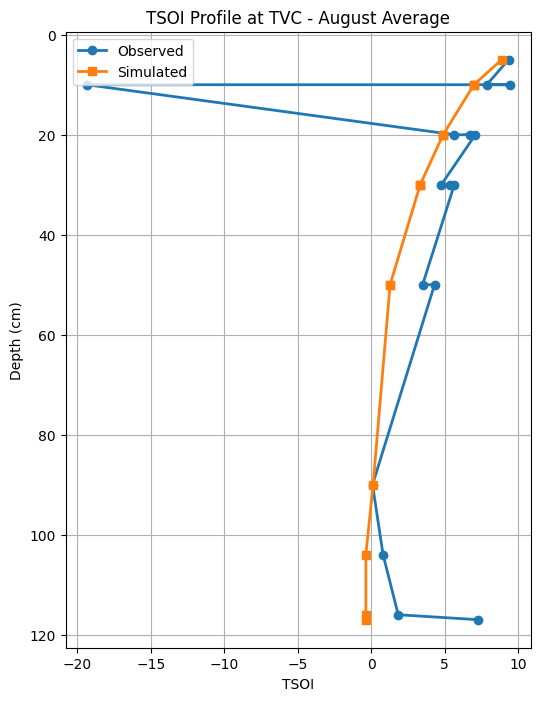

In [ ]:
# need to adjust to only include the closest duplicate

august_profile_tsoi(ds_obs, ds_ctsm, site, ds_obs.depth, f"{vari}", show=1)

# Seasonal Plot

In [ ]:
def seasonal_cycle_tsoi(obs, sim, site, used_xvals, vari, show=0):
    
    # Resample obs to daily
    obs_daily = obs.resample(time="1D").mean()
    # Convert sim K -> degC
    sim_c = sim - 273.15

    # Average over the relevant depths (same nearest-match logic as before)
    obs_depth_list = []
    sim_depth_list = []
    for act_val, raw_xval in used_xvals.items():
        obs_depth_list.append(obs_daily.sel(depth=raw_xval, method="nearest"))
        sim_depth_list.append(sim_c.sel(levgrnd=act_val, method="nearest"))

    obs_avg = xr.concat(obs_depth_list, dim="depth_sel").mean(dim="depth_sel", skipna=True)
    sim_avg = xr.concat(sim_depth_list, dim="depth_sel").mean(dim="depth_sel", skipna=True)

    # Monthly means, one value per year per month
    obs_monthly = obs_avg.resample(time="1M").mean(skipna=True)
    sim_monthly = sim_avg.resample(time="1M").mean(skipna=True)

    # Water-year order: Sep -> Aug
    month_order = [9, 10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8]
    month_labels = ["S", "O", "N", "D", "J", "F", "M", "A", "M", "J", "J", "A"]

    obs_mean, obs_min, obs_max = [], [], []
    sim_mean, sim_min, sim_max = [], [], []

    for m in month_order:
        ov = obs_monthly.sel(time=obs_monthly["time"].dt.month == m).values
        sv = sim_monthly.sel(time=sim_monthly["time"].dt.month == m).values
        ov = ov[~np.isnan(ov)]
        sv = sv[~np.isnan(sv)]

        obs_mean.append(np.mean(ov) if len(ov) else np.nan)
        obs_min.append(np.min(ov) if len(ov) else np.nan)
        obs_max.append(np.max(ov) if len(ov) else np.nan)

        sim_mean.append(np.mean(sv) if len(sv) else np.nan)
        sim_min.append(np.min(sv) if len(sv) else np.nan)
        sim_max.append(np.max(sv) if len(sv) else np.nan)

    x = np.arange(len(month_order))

    plt.figure(figsize=(8, 5))
    plt.plot(x, obs_mean, "-", color="gray", label="Observed", linewidth=2)
    plt.fill_between(x, obs_min, obs_max, color="gray", alpha=0.3)

    plt.plot(x, sim_mean, "-", color="crimson", label="Simulated", linewidth=2)
    plt.fill_between(x, sim_min, sim_max, color="crimson", alpha=0.3)

    plt.xticks(x, month_labels)
    plt.xlabel("Month")
    plt.ylabel(f"{vari}")
    plt.title(f"Seasonal Cycle of {vari} at {site} (depth-averaged)")
    plt.grid(True)
    plt.legend()
    plt.savefig(f"v1.0_final_images/{site}/{vari}/{site}_{vari}_seasonal.png")
    if not show:
        plt.close()

<string>:7: FutureWarning: 'M' is deprecated and will be removed in a future version. Please use 'ME' instead of 'M'.
<string>:7: FutureWarning: 'M' is deprecated and will be removed in a future version. Please use 'ME' instead of 'M'.


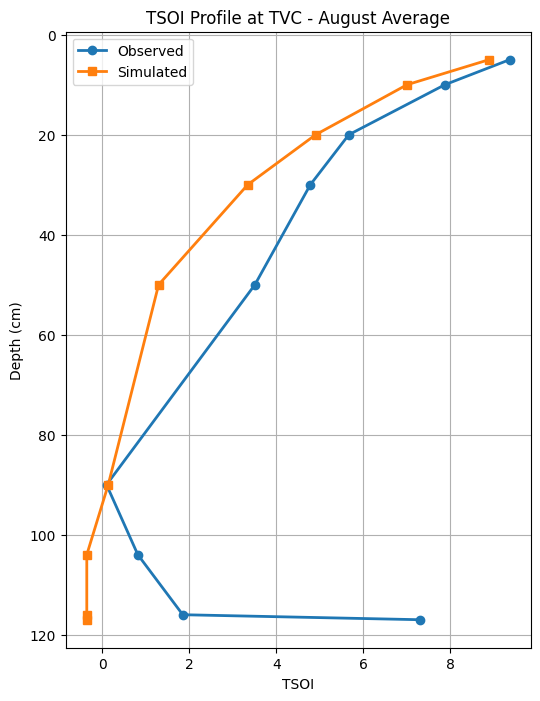

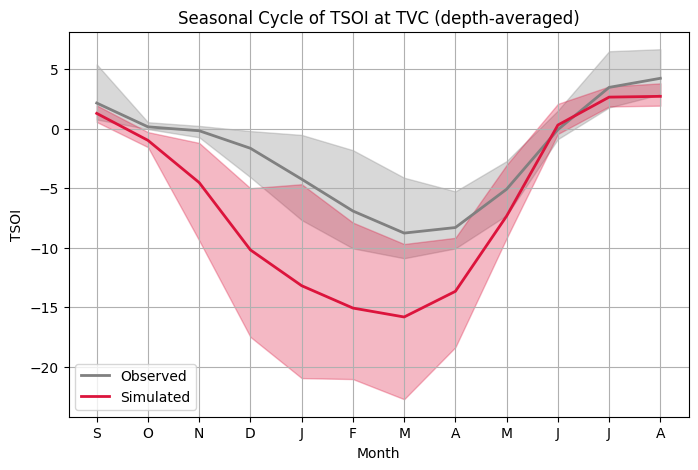

In [17]:
used = clean_august_profile_tsoi(ds_obs, ds_ctsm, site, ds_obs.depth, f"{vari}", show=1)
seasonal_cycle_tsoi(ds_obs, ds_ctsm, site, used, vari, show=1)

# Soil Profile

profile as a function of time


look at RMSE yearly and during seasons


D J F - winter

J J A - summer

## Soil Temperature Profiles for August

In [ ]:
# Load soil temperature — same structure as H2OSOI
st = ds["TSOI"].squeeze()          # shape: (time, levgrnd)
depths = ds["levgrnd"].values.flatten()

# Convert time once
cf_times = ds.indexes['time']
time_pd = pd.to_datetime([f"{t.year}-{t.month:02d}-{t.day:02d}" for t in cf_times])

# Build a DataArray with pandas time index
da_st = xr.DataArray(
    st.values,
    coords={"time": time_pd, "depth": depths},
    dims=["time", "depth"],
    attrs={"units": ds["TSOI"].attrs.get("units", "K"),
           "long_name": "Soil temperature"},
)

# Convert K to °C if needed
if da_st.attrs["units"] == "K":
    da_st = da_st - 273.15
    da_st.attrs["units"] = "°C"

# Filter to August only
da_aug = da_st.sel(time=da_st["time"].dt.month == 8)  # all Augusts across 20 years
print(f"August timesteps: {len(da_aug.time)}")         # should be ~20 x 31 = 620 days

#Individual August profiles, one line per year
years = np.unique(da_aug["time"].dt.year.values)
cmap  = cm.coolwarm(np.linspace(0, 1, len(years)))

fig, ax = plt.subplots(figsize=(10, 5))
for i, year in enumerate(years):
    aug_year = da_aug.sel(time=da_aug["time"].dt.year == year).mean(dim="time")
    ax.plot(aug_year.values, depths, color=cmap[i], linewidth=1.2, label=str(year))

ax.set_xlabel("Soil Temperature (°C)")
ax.set_ylabel("Depth (m)")
ax.set_title("August Soil Temperature Profile at Trail Valley Creek")
ax.invert_yaxis()
sm_cbar = plt.cm.ScalarMappable(cmap="coolwarm",
                                 norm=plt.Normalize(years.min(), years.max()))
plt.colorbar(sm_cbar, ax=ax, label="Year")
plt.tight_layout()
plt.show()


In [ ]:
# --- Plot 1: Mean August soil temperature profile ---
aug_mean = da_aug.mean(dim="time")
aug_std  = da_aug.std(dim="time")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(aug_mean.values, depths, color="tomato", linewidth=2, label="Mean")
ax.fill_betweenx(
    depths,
    aug_mean.values - aug_std.values,
    aug_mean.values + aug_std.values,
    alpha=0.3, color="tomato", label="±1 std"
)
ax.set_xlabel("Soil Temperature (°C)")
ax.set_ylabel("Depth (m)")
ax.set_title("Mean August Soil Temperature Profile (1995–2014)")
ax.invert_yaxis()   # surface at top
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:

# --- Plot 3: Heatmap — depth vs day-of-August, averaged across all years ---
da_aug_copy = da_aug.assign_coords(doy=("time", da_aug["time"].dt.day.values))
aug_by_day  = da_aug_copy.groupby("doy").mean()   # mean across all 20 Augusts per day

fig, ax = plt.subplots(figsize=(10, 5))
c = ax.contourf(
    aug_by_day["doy"].values,
    depths,
    aug_by_day.values.T,
    levels=25, cmap="RdYlBu_r"
)
plt.colorbar(c, ax=ax, label="Soil Temperature (°C)")
ax.set_xlabel("Day of August")
ax.set_ylabel("Depth (m)")
ax.set_title("August Soil Temperature by Depth (20-year average)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## NOTE

not sure if in this function, I need to be averaging over all AUgust for CTSM, or if I need the dat ranges to match

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_august_soil_temp_profile(obs_files: dict, da_aug, depths):
    """
    Plot mean August soil temperature profile comparing observations vs CTSM output.

    Parameters
    ----------
    obs_files : dict
        Keys are filenames like 'TVC_soil_temp_50.txt', values are DataFrames
        with columns [time, temp_c] (first col = time, second = temp).
    da_aug : xarray.DataArray
        CTSM August soil temperature data with dim 'time'.
    depths : array-like
        Depth values (in meters) for the CTSM soil layers.
    """

    # --- Parse observed data ---
    obs_records = []

    for filename, df in obs_files.items():
        depth_cm = float(filename.replace("TVC_soil_temp_", "").replace(".txt", ""))
        depth_m = depth_cm / 100.0

        df = df.copy()
        df.columns = ["time", "temp_c"]
        df["time"] = pd.to_datetime(df["time"])

        aug_df = df[df["time"].dt.month == 8]

        if aug_df.empty:
            print(f"Warning: no August data found in {filename}")
            continue

        obs_records.append({
            "depth_m":   depth_m,
            "mean_temp": aug_df["temp_c"].mean(),
            "std_temp":  aug_df["temp_c"].std(),
            "time_min":  df["time"].min(),
            "time_max":  df["time"].max(),
        })

    obs_df = pd.DataFrame(obs_records).sort_values("depth_m").reset_index(drop=True)

    # --- Compute obs depth and time range ---
    depth_min = obs_df["depth_m"].min()
    depth_max = obs_df["depth_m"].max() + 0.25
    time_min  = obs_df["time_min"].min()
    time_max  = obs_df["time_max"].max()

    print(f"Restricting CTSM to depths {depth_min}–{depth_max} m "
          f"and time {time_min.date()}–{time_max.date()}")

    # --- Mask CTSM by depth ---
    depths = np.array(depths)
    depth_mask      = (depths >= depth_min) & (depths <= depth_max)
    depths_masked   = depths[depth_mask]

    # --- Mask CTSM by time ---
    ctsm_times = pd.to_datetime(da_aug["time"].values).tz_localize(None)
    time_min   = time_min.tz_localize(None) if time_min.tzinfo else time_min
    time_max   = time_max.tz_localize(None) if time_max.tzinfo else time_max

    time_mask     = (ctsm_times >= time_min) & (ctsm_times <= time_max)
    da_aug_masked = da_aug.isel(time=time_mask)

    # --- Compute CTSM mean/std over masked time, then mask depth ---
    aug_mean = da_aug_masked.mean(dim="time").values[depth_mask]
    aug_std  = da_aug_masked.std(dim="time").values[depth_mask]

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(6, 6))

    # CTSM
    ax.plot(aug_mean, depths_masked,
            color="tomato", linewidth=2, label="CTSM Mean")
    # ax.fill_betweenx(depths_masked,
    #                  aug_mean - aug_std,
    #                  aug_mean + aug_std,
    #                  alpha=0.3, color="tomato", label="CTSM ±1 std")

    # Observed
    ax.plot(obs_df["mean_temp"], obs_df["depth_m"],
            color="steelblue", linewidth=2, marker="o", label="Observed Mean")
    # ax.fill_betweenx(obs_df["depth_m"],
    #                  obs_df["mean_temp"] - obs_df["std_temp"],
    #                  obs_df["mean_temp"] + obs_df["std_temp"],
    #                  alpha=0.3, color="steelblue", label="Obs ±1 std")

    ax.set_xlabel("Soil Temperature (°C)")
    ax.set_ylabel("Depth (m)")
    ax.set_title("August Soil Temperature Profile at Trail Valley Creek")
    ax.set_ylim(0, depth_max)
    ax.set_xlim(-2,20)
    ax.axvline(0, color="black", linewidth=0.9, linestyle="--", alpha=0.35, zorder=2)
    ax.invert_yaxis()
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"0_final_images/TVC_soil_temp_profile.png")
    plt.show()

In [ ]:
plot_august_soil_temp_profile(observe, da_aug, depths)